# Data Speaks!! — Student Performance Analysis
**Dataset:** UCI Student Performance Data Set (Math course) — Cortez & Silva, 2008
**Goal:** Clean the data, explore it, and understand what factors (besides prior grades) predict a student's final exam score (G3).

This notebook covers:
1. Load & inspect the data
2. Clean & preprocess
3. Exploratory Data Analysis (EDA)
4. Encode categorical variables for modeling
5. Save the cleaned dataset for the regression step


## 1. Load & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/student-mat.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [3]:
# Check for missing values and duplicate rows
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
 0 total missing values
Duplicate rows: 0


**Observation:** This dataset has no missing values and no duplicates — it was already fairly clean when donated to UCI.
Our "cleaning" work here is mostly about checking for weird values and preparing the categorical columns for modeling.

## 2. Clean & Preprocess

In [4]:
# Sanity check numeric ranges (catch impossible values, e.g. negative ages or grades > 20)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe().T[["min", "max", "mean"]]

,min,max,mean
age,15.0,22.0,16.696203
Medu,0.0,4.0,2.749367
Fedu,0.0,4.0,2.521519
traveltime,1.0,4.0,1.448101
studytime,1.0,4.0,2.035443
failures,0.0,3.0,0.334177
famrel,1.0,5.0,3.944304
freetime,1.0,5.0,3.235443
goout,1.0,5.0,3.108861
Dalc,1.0,5.0,1.481013


In [5]:
# All values are within expected ranges (grades 0-20, ages 15-22, etc.)
# Identify binary yes/no columns and multi-category columns for encoding later
binary_cols = ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]
for col in binary_cols:
    print(col, df[col].unique())

schoolsup <StringArray>
['yes', 'no']
Length: 2, dtype: str
famsup <StringArray>
['no', 'yes']
Length: 2, dtype: str
paid <StringArray>
['no', 'yes']
Length: 2, dtype: str
activities <StringArray>
['no', 'yes']
Length: 2, dtype: str
nursery <StringArray>
['yes', 'no']
Length: 2, dtype: str
higher <StringArray>
['yes', 'no']
Length: 2, dtype: str
internet <StringArray>
['no', 'yes']
Length: 2, dtype: str
romantic <StringArray>
['no', 'yes']
Length: 2, dtype: str


In [6]:
# Map binary yes/no columns to 1/0 (keeps the dataset numeric-friendly for modeling)
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Same for sex, school, address, famsize, Pstatus (binary categorical, not yes/no)
df["sex"] = df["sex"].map({"F": 1, "M": 0})           # 1 = Female
df["school"] = df["school"].map({"GP": 1, "MS": 0})   # 1 = Gabriel Pereira
df["address"] = df["address"].map({"U": 1, "R": 0})   # 1 = Urban
df["famsize"] = df["famsize"].map({"GT3": 1, "LE3": 0}) # 1 = family > 3 members
df["Pstatus"] = df["Pstatus"].map({"T": 1, "A": 0})   # 1 = parents living together

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,1,1,18,1,1,0,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,1,1,17,1,1,1,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,1,1,15,1,0,1,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,1,1,15,1,1,1,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,1,1,16,1,1,1,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
# One-hot encode the remaining multi-category columns (Mjob, Fjob, reason, guardian)
multi_cat_cols = ["Mjob", "Fjob", "reason", "guardian"]
df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (395, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,1,1,18,1,1,0,4,4,2,2,...,False,False,False,False,True,False,False,False,True,False
1,1,1,17,1,1,1,1,1,1,2,...,False,False,True,False,False,False,False,False,False,False
2,1,1,15,1,0,1,1,1,1,2,...,False,False,True,False,False,False,True,False,True,False
3,1,1,15,1,1,1,4,2,1,3,...,False,False,False,True,False,True,False,False,True,False
4,1,1,16,1,1,1,3,3,1,2,...,False,False,True,False,False,True,False,False,False,False


## 3. Exploratory Data Analysis (EDA)

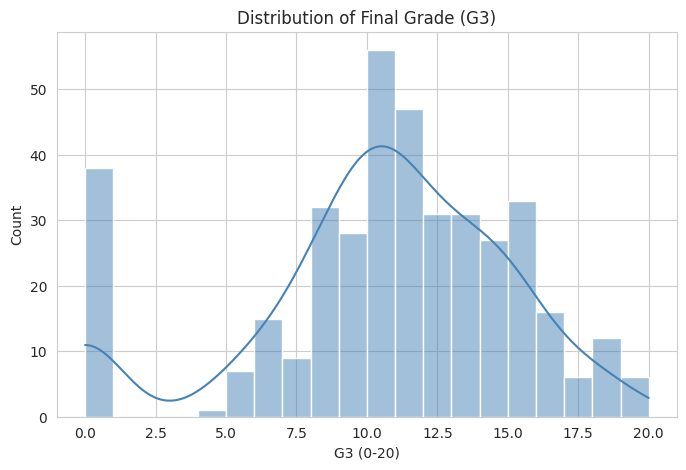

In [8]:
# Distribution of the target variable: final grade (G3)
plt.figure()
sns.histplot(df["G3"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("G3 (0-20)")
plt.savefig("../outputs_temp/g3_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

/tmp/ipykernel_541/570872330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="studytime", y="G3", palette="Blues")


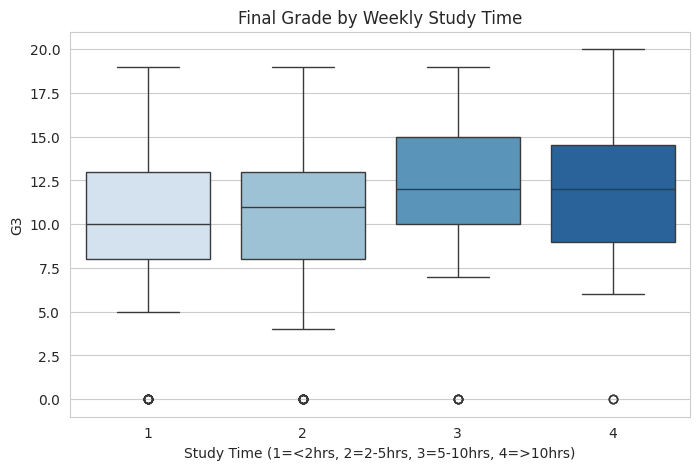

In [9]:
# How does study time relate to final grade?
plt.figure()
sns.boxplot(data=df, x="studytime", y="G3", palette="Blues")
plt.title("Final Grade by Weekly Study Time")
plt.xlabel("Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)")
plt.ylabel("G3")
plt.savefig("../outputs_temp/g3_by_studytime.png", dpi=120, bbox_inches="tight")
plt.show()

/tmp/ipykernel_541/474570581.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="failures", y="G3", palette="Reds")


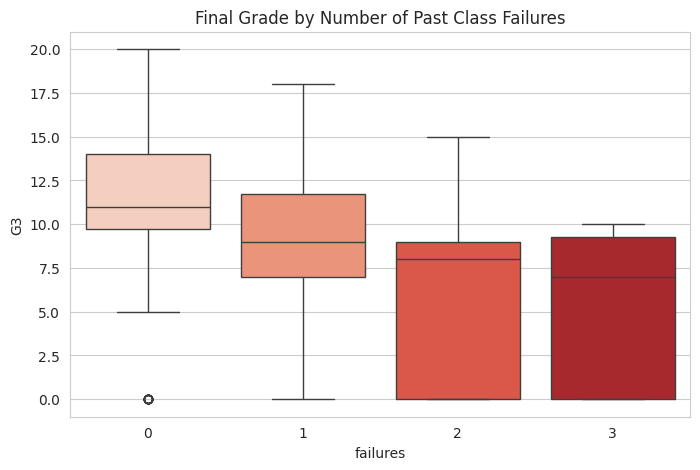

In [10]:
# Does number of past failures matter?
plt.figure()
sns.boxplot(data=df, x="failures", y="G3", palette="Reds")
plt.title("Final Grade by Number of Past Class Failures")
plt.savefig("../outputs_temp/g3_by_failures.png", dpi=120, bbox_inches="tight")
plt.show()

/tmp/ipykernel_541/3948991444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Medu", y="G3", ax=axes[0], palette="Greens")
/tmp/ipykernel_541/3948991444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fedu", y="G3", ax=axes[1], palette="Purples")


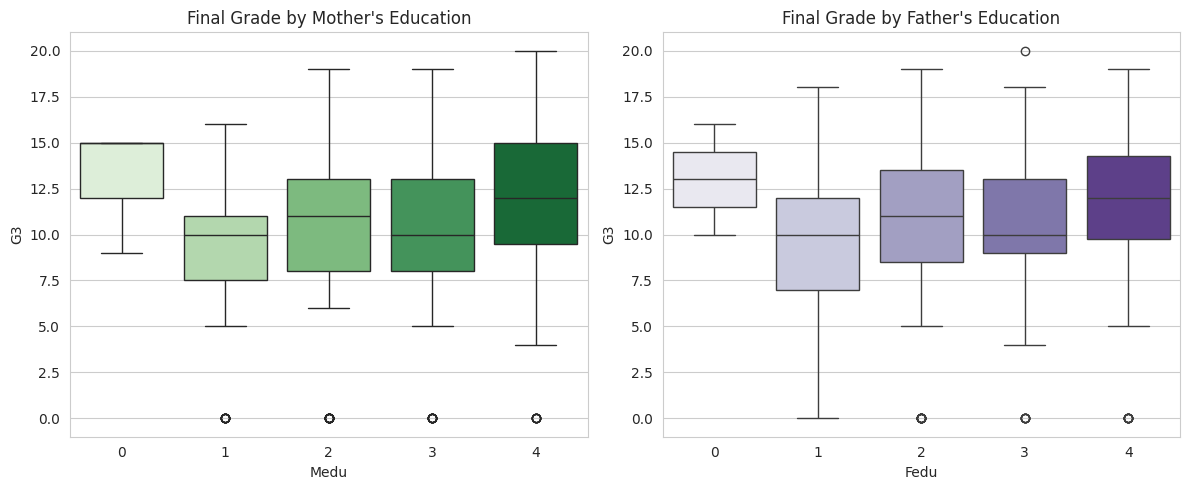

In [11]:
# Parental education vs final grade
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Medu", y="G3", ax=axes[0], palette="Greens")
axes[0].set_title("Final Grade by Mother's Education")
sns.boxplot(data=df, x="Fedu", y="G3", ax=axes[1], palette="Purples")
axes[1].set_title("Final Grade by Father's Education")
plt.tight_layout()
plt.savefig("../outputs_temp/g3_by_parent_edu.png", dpi=120, bbox_inches="tight")
plt.show()

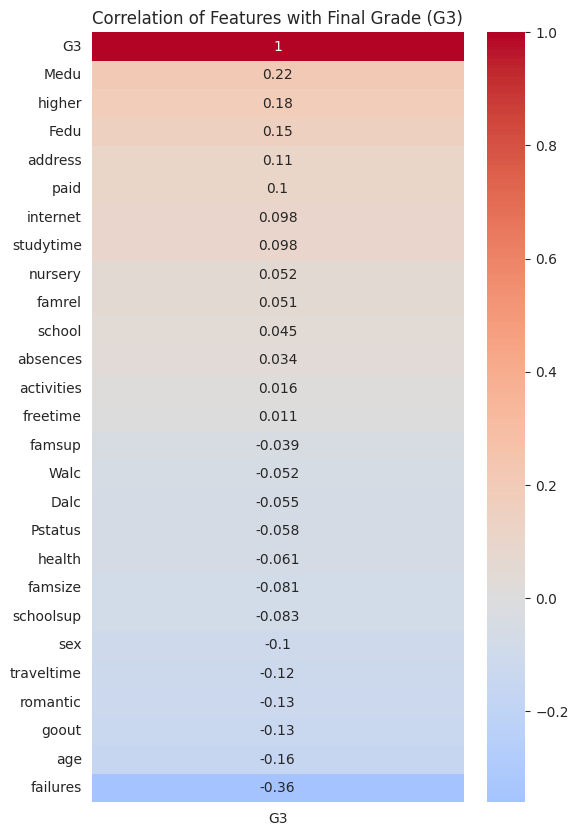

In [12]:
# Correlation heatmap of numeric features against G3 (excluding G1, G2 since we're not using them as predictors)
corr_cols = [c for c in df.columns if c not in ["G1", "G2"]]
numeric_for_corr = df[corr_cols].select_dtypes(include=[np.number])
corr = numeric_for_corr.corr()[["G3"]].sort_values("G3", ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Features with Final Grade (G3)")
plt.savefig("../outputs_temp/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
print("Top positive correlations with G3:")
print(corr.sort_values("G3", ascending=False).head(6))
print("\nTop negative correlations with G3:")
print(corr.sort_values("G3").head(6))

Top positive correlations with G3:
               G3
G3       1.000000
Medu     0.217147
higher   0.182465
Fedu     0.152457
address  0.105756
paid     0.101996

Top negative correlations with G3:
                  G3
failures   -0.360415
age        -0.161579
goout      -0.132791
romantic   -0.129970
traveltime -0.117142
sex        -0.103456


### EDA Notes (fill these in as you look at the plots — you'll need this for your report)
- Final grades (G3) are roughly [describe shape — normal? skewed? spike at 0?]
- Study time [does more study time clearly raise grades, or is the effect weak?]
- Past failures [how strong is the negative effect?]
- Parental education [any visible trend?]
- Strongest correlated features with G3, besides G1/G2: [list top 3-5 from the cell above]


## 4. Save Cleaned & Encoded Dataset

In [14]:
df_encoded.to_csv("student_mat_cleaned.csv", index=False)
print("Saved cleaned dataset:", df_encoded.shape)

Saved cleaned dataset: (395, 42)


**Next step:** Use `student_mat_cleaned.csv` in the regression notebook to predict `G3` using all features *except* `G1` and `G2` (the harder, more insightful version of the problem).